In [1]:
%reload_ext autoreload
%autoreload 2

In [114]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from probjax.nn import MLP, GaussianFourierEmbedding
from probjax.nn.nets.denoising_diffusion_model import EDM, VE, VP

from probjax.nn.utils import ot_copula


In [117]:
d = 2

In [118]:
def generate_data(key):
    # Mixture of Gaussians
    key, subkey = jax.random.split(key)
    u = jax.random.uniform(subkey)
    eps = jax.random.normal(subkey, (2,d))
    x = jnp.where(u < 0.5, eps[0]-3., eps[1]+3)
    return x

[3.181 3.137]


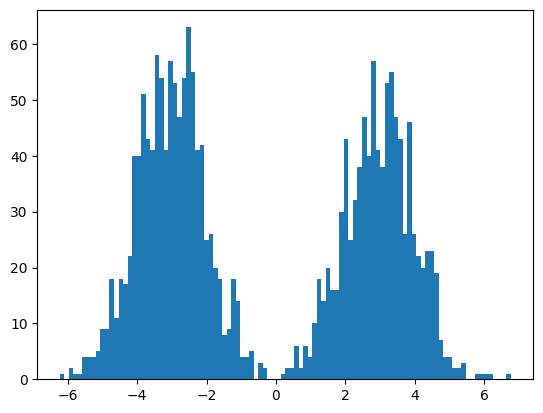

In [119]:
xs = jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 1000))
print(xs.std(0))
_ = plt.hist(xs.flatten(), bins=100)

In [135]:
d = 2
class BaseModel(nnx.Module, experimental_pytree=True):
    def __init__(self, d, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,4, rngs=rngs)
        #self.time_embedding = lambda t: jnp.repeat(t, 5, axis=-1)
        self.mlp = MLP([d+4,50,50,50,d], rngs=rngs)

    def __call__(self, t,x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        inp = jnp.concatenate([time_embed, x], axis=-1)
        output = self.mlp(inp)
        return output

net = BaseModel(d, nnx.Rngs(0))
model = EDM(net, std0=1.)
params = nnx.state(model, nnx.Param)

In [136]:

import optax

opt = optax.chain(optax.adaptive_grad_clip(1.), optax.adam(1e-3))
opt_state = opt.init(params)
@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(model.loss)(params, rng,x)
    updates, opt_state = opt.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [137]:
key = jax.random.key(0)

In [138]:
losses = []
for i in range(20):
    l = 0.
    for j in range(10):
        key,key_data, key_loss = jax.random.split(key, 3)
        xs = jax.vmap(generate_data)(jax.random.split(key_data, 100))
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    print(l/10)
    losses.append(l/10)

4.8214083
3.7603989
3.6381917
3.196306
3.0033433
2.729618
2.6785808
2.5702207
2.380571
2.4305499
2.2859547
2.3397062
2.369662
2.409519
2.2500865
2.3295047
2.5072472
2.2346227
2.2030842
2.3456686


In [126]:
nnx.update(model, params)

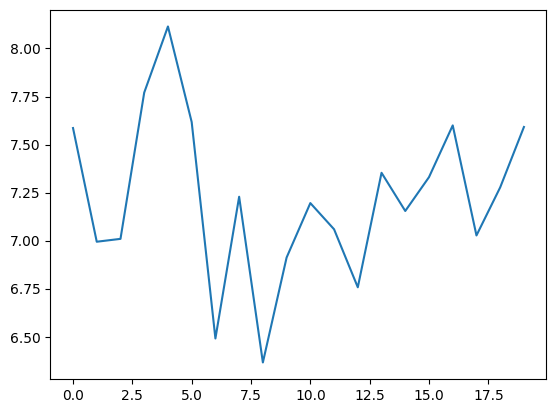

In [127]:
plt.plot(losses)

In [128]:
from probjax.utils.odeint import odeint


def sample(rng):
    eps = jax.random.normal(rng, (d,)) * model.marginal_std(model.max_noise)
    ts = model.solve_schedule()

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x)
        return (f -0.5*g**2*score).reshape(x.shape)

    return odeint(drift, eps,ts, method="heun")


In [129]:
keys = jax.random.split(key, (10_000,))
xs = jax.vmap(sample)(keys)

(-10.0, 10.0)

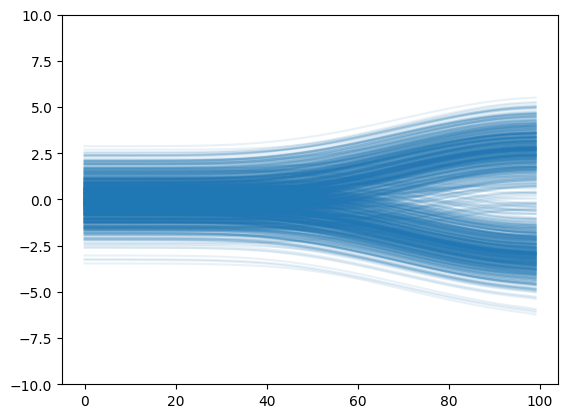

In [130]:
_ = plt.plot(xs[::10,:,0].T, color="C0", alpha=0.1)
plt.ylim(-10,10)

(-7.0, 7.0)

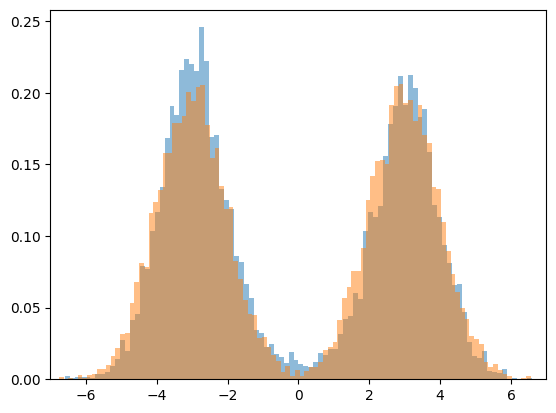

In [56]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, range=(-7,7), alpha=0.5)
_ = plt.hist(jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 10000)).flatten(), bins=100, density=True, alpha=0.5)

plt.xlim(-7,7)

In [57]:
from probjax.utils.sdeint import sdeint


def sample(rng):
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (d,))  * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(50)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t,x)
        score = model.score(t,x)

        drift_backward = f - g**2 * score
        return drift_backward

    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        g = model.diffusion(t,x)
        return g

    return sdeint(rng_sample,drift, diffusion, eps, ts, method="euler_maruyama")


In [58]:
keys = jax.random.split(key, (10_000,))

In [59]:
xs = jax.vmap(sample)(keys)

(-10.0, 10.0)

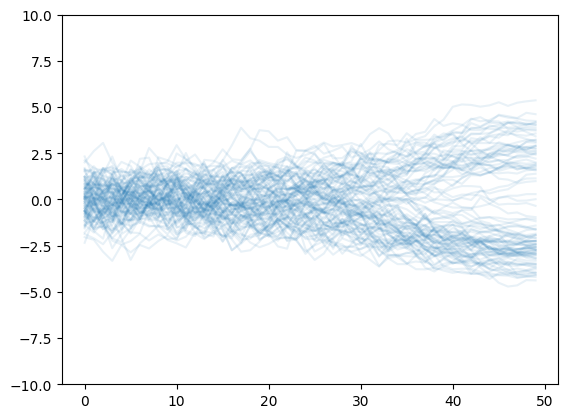

In [60]:
_ = plt.plot(xs[::100,:,0].T, color="C0", alpha=0.1)
plt.ylim(-10,10)

(-7.0, 7.0)

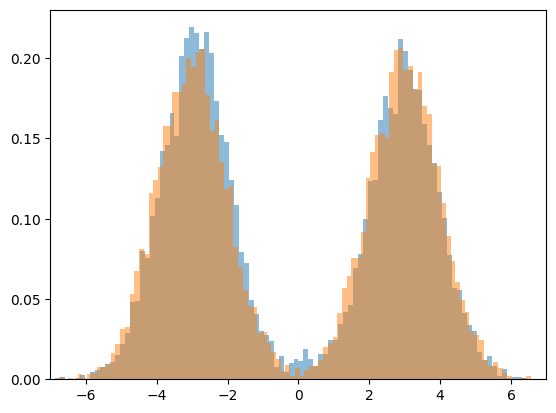

In [61]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, range=(-7,7), alpha=0.5)
_ = plt.hist(jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 10000)).flatten(), bins=100, density=True, alpha=0.5)

plt.xlim(-7,7)